In [ ]:
import sys
import os
import time

from SelfCal import PipelineWrapper
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, \
load_calibration, make_spherex_offset_map, compute_offsets_guess, load_lvf_params, compute_vertical_strip_adjacency, \
make_stripped_chunk_map, make_stripped_chunk_valid_mask, make_spherex_stripped_offset_map, fast_vertical_dist
from SelfCal.SPHERExAppendWav import wav_coadd

from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
mpl.rcParams['figure.dpi'] = 200
# Import LogNorm
from tqdm import tqdm
import gc
from functools import partial
import sys
import os
import shutil

from SelfCal.SPHERExUtility import load_calibration, load_lvf_params, compute_vertical_strip_adjacency, \
make_stripped_chunk_map, make_stripped_chunk_valid_mask, make_spherex_stripped_offset_map, fast_vertical_dist
from SelfCal.SPHERExAppendWav import wav_coadd

SyntaxError: invalid syntax (3272167792.py, line 29)

In [2]:
def prepare_detector_inputs(frame_setting, calibration_setting, mosaic_setting):
    detector = frame_setting['Detector']
    num_subchannels = frame_setting['NumSub']
    num_channels = frame_setting['NumCh']
    num_columns = frame_setting['NumCol']
    oversample_factor = mosaic_setting['OversampleFactor']

    lvf_filename = f'lvf_params_D{detector}.npy'
    lvf_params = load_lvf_params(lvf_filename)

    det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
    grid_chunk_map, _, _, _ = make_stripped_chunk_map(detector, num_subchannels=num_subchannels, num_channels=num_channels, num_columns=num_columns,
                                                    oversample_factor=oversample_factor, lvf_params=lvf_params)
    det_chunk_map, _, r_edges, x_edges = make_stripped_chunk_map(detector, num_subchannels=num_subchannels, num_channels=num_channels, num_columns=num_columns,
                                            oversample_factor=1, lvf_params=lvf_params)
    detector_inputs = {
        'lvf_params': lvf_params,
        'det_BC': det_BC,
        'det_BW': det_BW,
        'grid_chunk_map': grid_chunk_map,
        'det_chunk_map': det_chunk_map,
        'r_edges': r_edges,
        'x_edges': x_edges
    }
    return detector_inputs

def prepare_channel_inputs(ch, frame_setting):
    num_subchannels = frame_setting['NumSub']
    num_channels = frame_setting['NumCh']
    num_columns = frame_setting['NumCol']
     # Prepare masks
    chunk_valid_mask_padded = make_stripped_chunk_valid_mask(ch, num_subchannels=num_subchannels, num_channels=num_channels, 
                                        num_columns=num_columns, subchannel_padding=1)
    chunk_valid_mask = make_stripped_chunk_valid_mask(ch, num_subchannels=num_subchannels, num_channels=num_channels, 
                                        num_columns=num_columns, subchannel_padding=0)

    channel_inputs = {
        'chunk_valid_mask_padded': chunk_valid_mask_padded,
        'chunk_valid_mask': chunk_valid_mask
    }
    return channel_inputs


In [3]:
# ----------------------------- Start of Settings -----------------------------
frame_setting = {
    'Detector': 4,
    'NumSub': 10,
    'NumCh': 34,
    'NumCol': 5,
}

calibration_setting = {
    'ApplyMask': True,
    'ApplyWeight': False,
    'OutlierThresh': 2.0,
    'IgnoreList': [],
    'OffsetRegularization': True,
    'RegWeight': 10.0,
    'WeightedDamping': True,
    'DampWeight': 100.0,
}

mosaic_setting = {
    'ApplyMask': True,
    'ApplyWeight': False,
    'MakeStdMap': True,
    'ApplySigmaClipping': True,
    'Sigma': 1.0,
    'IgnoreList': [21],
    'OversampleFactor': 2,
}

CACHE_DIR = '/home/thomasli/spherex/selfcal/cache/'
FILE_SUFFIX = f'_Control'

selfcal_config = {}
selfcal_config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
selfcal_config['run_name'] = f'SPHEREx_nep_qr2_det{frame_setting["Detector"]}_6p2arcsec'
selfcal_config['resolution_arcsec'] = 6.2

In [4]:
frame_setting_str = '_'.join([f'{key}{value}' for key, value in frame_setting.items()])
detector_inputs = prepare_detector_inputs(frame_setting, calibration_setting, mosaic_setting)
# chs = [[8], [9], [10], [11], [12], [13], [14], [15], [16]]
# chs = [[17], [18], [19], [20], [21], [22], [23], [24], [25]]
chs = [[8]]
channel_jobs = {
    f'Ch{"-".join(map(str, ch))}': prepare_channel_inputs(ch, frame_setting) for ch in chs
}


Loaded LVF parameters from /home/thomasli/spherex/selfcal/selfcal_scripts/lvf_params/lvf_params_D4.npy


  1%|█                                                                                                                            | 3/341 [00:00<00:12, 27.60it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:02<00:00, 139.23it/s]


In [5]:
job_name, channel_inputs = list(channel_jobs.items())[0]

In [ ]:
print(f"Processing channel {job_name} for detector {frame_setting['Detector']}...")

# Prepare inputs
chunk_valid_mask_padded = channel_inputs['chunk_valid_mask_padded']
chunk_valid_mask = channel_inputs['chunk_valid_mask']
adj_info = compute_vertical_strip_adjacency(detector_inputs['det_chunk_map'], frame_setting['NumCol'])
job_tag = f'{frame_setting_str}_{job_name}{FILE_SUFFIX}'
cal_file = f'cal_{job_tag}.h5'
mos_file = f"mosaic_{job_tag}.fits"

# Calibration
cc = PipelineWrapper.Calibrator(selfcal_config, chunk_map=detector_inputs['det_chunk_map'])
cal_path = os.path.join(cc.config['cal_dir'], cal_file)
# if os.path.exists(cal_path):
#     print(f"Calibration file {cal_path} already exists. Skipping calibration and mosaicking for channel {job_name}.")
# else:
det_valid_mask = chunk_valid_mask_padded[detector_inputs['det_chunk_map']]
det_valid_weight = fast_vertical_dist(det_valid_mask)
det_valid_weight /= np.max(det_valid_weight)  # Normalize weights to [0, 1]
# det_valid_weight[det_valid_mask>0] = 0.5 + 0.5 * det_valid_weight[det_valid_mask>0]  # Scale to [0.5, 1]
cc.setup_lsqr(
    apply_mask=calibration_setting['ApplyMask'], 
    apply_weight=calibration_setting['ApplyWeight'],
    grid_valid_weight=det_valid_mask, 
    max_workers=50, 
    outlier_thresh=calibration_setting['OutlierThresh'],
    ignore_list=calibration_setting['IgnoreList'],
    oversample_factor=1,
    batch_size=40,
    offset_regularization=calibration_setting['OffsetRegularization'],
    reg_weight=calibration_setting['RegWeight'],
    adj_info=adj_info,
    weighted_damping=calibration_setting['WeightedDamping'],
    damp_weight=calibration_setting['DampWeight'],
    )

Processing channel Ch8 for detector 4...
Computing Vertical Strip Adjacency (Filtering Arcs)...
Found 1367 vertical strip boundaries.


  0%|                                                                                                                                   | 0/13184 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 1377861.21it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Processing 13184 items in 330 batches...



Building A, b matrix:  83%|███████████████████████████████████████████████████████████████████████████████████▌                 | 273/330 [13:59<03:44,  3.93s/it]

In [ ]:
cc.apply_lsqr(x0=None, atol=1e-06, btol=1e-06, damp=1e-3, iter_lim=100, precondition=False)
cal_path = cc.save_calibration(cal_file=cal_file)

Solving least squares for 175557051 unknowns with 663486021 equations.
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 663486021 rows and 175557051 columns
damp = 1.00000000000000e-03   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =      100
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   1.971e+03  1.971e+03    1.0e+00  1.5e-02
     1  0.00000e+00   9.199e+02  9.199e+02    4.7e-01  1.9e+00   3.2e+01  1.0e+00
     2  0.00000e+00   5.241e+02  5.241e+02    2.7e-01  4.8e-01   8.9e+01  3.2e+00
     3  0.00000e+00   4.049e+02  4.049e+02    2.1e-01  3.2e-01   1.1e+02  4.6e+00
     4  0.00000e+00   3.325e+02  3.325e+02    1.7e-01  2.8e-01   1.4e+02  6.2e+00
     5  0.00000e+00   2.741e+02  2.741e+02    1.4e-01  2.2e-01   1.7e+02  8.2e+00
     6  0.00000e+00   2.325e+02  2.325e+02    1.2e-01  1.5e-01   1.9e+02  1.0e+01
     7  0.00000e+00   2.115e+02  2.

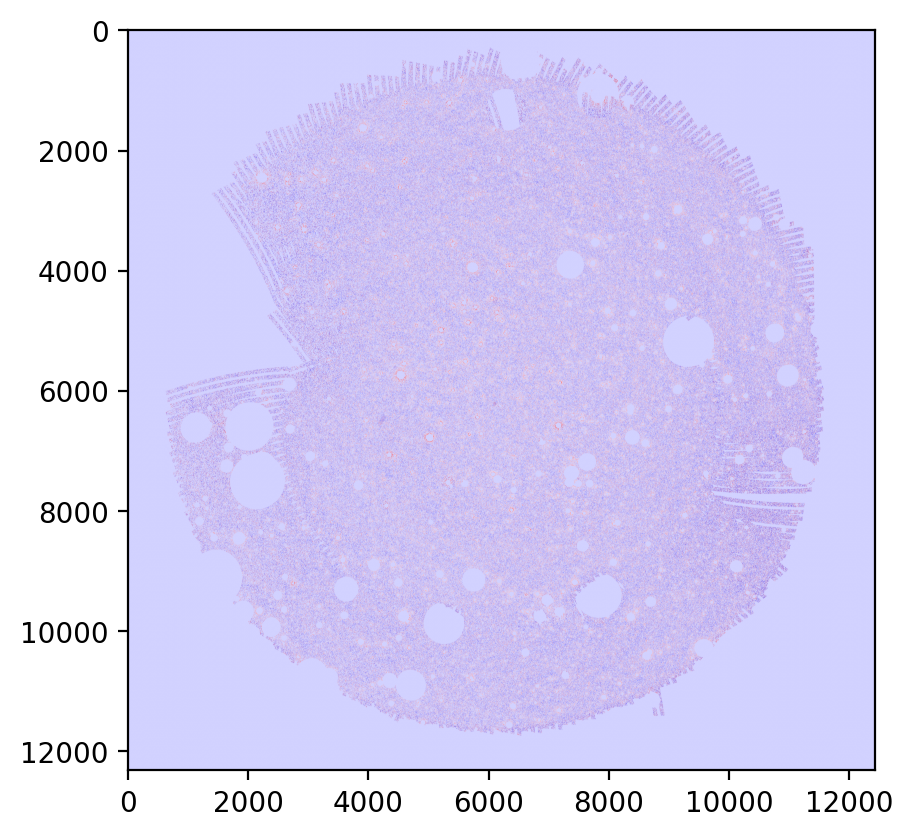

In [41]:
skymap = cc.get_skymap()
vmin, vmax = np.nanpercentile(skymap[np.nonzero(skymap)], [1, 99])
plt.imshow(skymap, vmin=vmin, vmax=vmax, cmap='bwr')

In [43]:
partial_make_offset_map = partial(make_spherex_stripped_offset_map,
                            chunk_valid_mask=chunk_valid_mask, 
                            lvf_params=detector_inputs['lvf_params'], 
                            r_edges=detector_inputs['r_edges'], 
                            x_edges=detector_inputs['x_edges'], 
                            tot_subchannels=frame_setting['NumSub']*frame_setting['NumCh']+2, 
                            num_columns=frame_setting['NumCol'],
                            fill_invalid=True)

mm = PipelineWrapper.Mosaicker(selfcal_config, chunk_map=detector_inputs['grid_chunk_map'])
mm.load_calibration(cal_path=cal_path)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 1268848.90it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_Detector4_NumSub10_NumCh34_NumCol5_Ch8_Control.h5


In [50]:

cache_dir = f'{CACHE_DIR}cache_{job_tag}'
grid_valid_mask = chunk_valid_mask_padded[detector_inputs['grid_chunk_map']]
grid_valid_weight = fast_vertical_dist(grid_valid_mask)
grid_valid_weight /= np.max(grid_valid_weight)  # Normalize weights to [0, 1]
# grid_valid_weight[grid_valid_mask>0] = 0.5 + 0.5 * grid_valid_weight[grid_valid_mask>0]  # Scale to [0.5, 1]
maps = mm.make_mosaic(
    apply_mask=mosaic_setting['ApplyMask'], 
    apply_weight=mosaic_setting['ApplyWeight'], 
    grid_valid_weight=grid_valid_weight, 
    max_workers=50,
    make_std_map=False, 
    apply_sigma_clipping=False,  
    sigma=mosaic_setting['Sigma'],
    ignore_list=mosaic_setting['IgnoreList'],
    oversample_factor=mosaic_setting['OversampleFactor'],
    det_offset_func=partial_make_offset_map,#partial_make_offset_map,
    cache_batch_size=40,
    coadd_batch_size=100,
    cache_dir=cache_dir,
    cache_intermediate=False,
    det_aux=None
)


Computing mean map...
Processing 13184 files in 132 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [23:20<00:00, 10.61s/it]


Mean map computation finished in 1412.31 seconds.


In [51]:
mosaic = mm.maps['mean_map']['data']

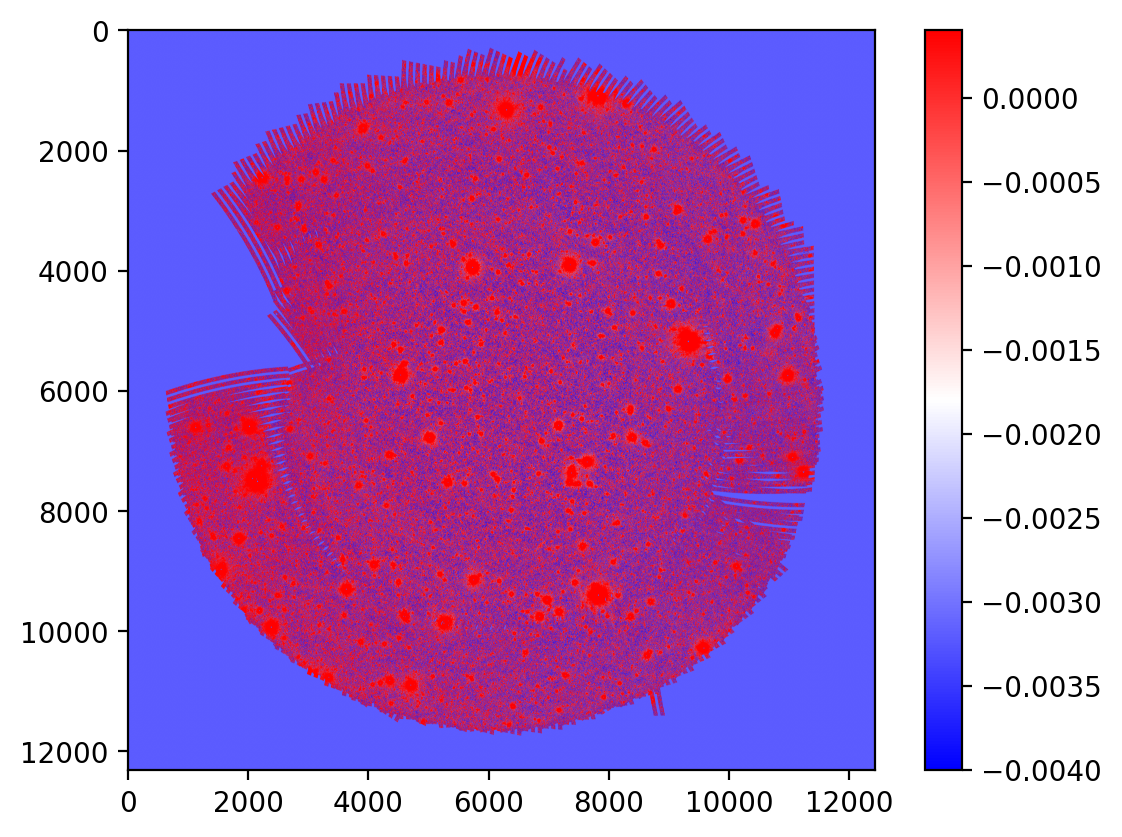

In [52]:
plt.imshow(mosaic-np.nanmedian(mosaic[np.nonzero(mosaic)]), vmin=-0.004, vmax=0.0004, cmap='bwr')
plt.colorbar()